In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,3583,2025-09-21 03:01:00,click,46,Unisex,Converse Unisex Red Basic Flip Flops,Converse,299.0,299.0,...,Red,Spring,2013,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,<p>Red coloured flip flops<br />Thong style up...
1,1,9638,2025-09-21 03:02:00,click,46,Unisex,Puma Unisex MM II Blue Flip Flop,Puma,499.0,499.0,...,Blue,Spring,2012,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,"<p style=""text-align: justify;"">Chill out in s..."
2,1,1679,2025-09-21 03:05:00,click,46,Unisex,Converse Unisex Black Flip Flops,Converse,299.0,299.0,...,Black,Spring,2013,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,<p>Black flip flops<br />Thong style upper wit...
3,1,6133,2025-09-21 03:04:00,click,46,Unisex,Puma Unisex Wave Green Flip Flops,Puma,599.0,599.0,...,Green,Spring,2012,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,<p>This absolutely stylish pair of Wave IND fl...
4,1,113,2025-09-21 03:17:00,click,46,Unisex,Puma Unisex Arizona Light Blue White Flip Flop,Puma,399.0,399.0,...,Blue,Spring,2012,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,"<p style=""text-align: justify;"">A stroll on th..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("transformer:latest")
reg_model_artifact = bentoml.models.get("regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
0,7530,1,5,"[0, 0, 0, 0, 0]","[ESPRIT, Titan, Gatsby, ADIDAS, Playboy]","[Women, Women, Men, Men, Men]","[Adults-Women, Adults-Women, Adults-Men, Adult...","[Steel, Gold, Blue, Blue, Black]","[Winter, Winter, Spring, Spring, Spring]","[2016, 2016, 2017, 2017, 2017]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Personal Care, Pers...","[Watches, Watches, Fragrance, Fragrance, Fragr...","[Watches, Watches, Deodorant, Deodorant, Deodo...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, click]","[3280, 341, 2859, 8977, 5820]","[341, 2859, 8977, 5820, 4840]"
1,7530,2,5,"[0, 0, 0, 0, 0]","[maxima, ESPRIT, Titan, Gatsby, ADIDAS]","[Women, Women, Women, Men, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[White, Steel, Gold, Blue, Blue]","[Winter, Winter, Winter, Spring, Spring]","[2016, 2016, 2016, 2017, 2017]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Person...","[Watches, Watches, Watches, Fragrance, Fragrance]","[Watches, Watches, Watches, Deodorant, Deodorant]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, click]","[4195, 3280, 341, 2859, 8977]","[3280, 341, 2859, 8977, 5820]"
2,7530,3,5,"[0, 0, 0, 0, 0]","[Red Tape, Fastrack, GIORDANO, maxima, ESPRIT]","[Men, Women, Women, Women, Women]","[Adults-Men, Adults-Women, Adults-Women, Adult...","[Black, Grey, Blue, White, Steel]","[Winter, Winter, Winter, Winter, Winter]","[2018, 2016, 2016, 2016, 2016]","[Formal, Casual, Casual, Casual, Casual]","[Footwear, Accessories, Accessories, Accessori...","[Shoes, Watches, Watches, Watches, Watches]","[Formal Shoes, Watches, Watches, Watches, Watc...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[cart, click, click, click, click]","[5300, 5929, 6200, 4195, 3280]","[5929, 6200, 4195, 3280, 341]"
3,7530,4,5,"[0, 0, 0, 0, 0]","[GIORDANO, maxima, ESPRIT, Titan, Gatsby]","[Women, Women, Women, Women, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Blue, White, Steel, Gold, Blue]","[Winter, Winter, Winter, Winter, Spring]","[2016, 2016, 2016, 2016, 2017]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Access...","[Watches, Watches, Watches, Watches, Fragrance]","[Watches, Watches, Watches, Watches, Deodorant]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, click]","[6200, 4195, 3280, 341, 2859]","[4195, 3280, 341, 2859, 8977]"
4,7530,5,5,"[0, 0, 0, 0, 0]","[Fastrack, GIORDANO, maxima, ESPRIT, Titan]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Grey, Blue, White, Steel, Gold]","[Winter, Winter, Winter, Winter, Winter]","[2016, 2016, 2016, 2016, 2016]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Access...","[Watches, Watches, Watches, Watches, Watches]","[Watches, Watches, Watches, Watches, Watches]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, click]","[5929, 6200, 4195, 3280, 341]","[6200, 4195, 3280, 341, 2859]"
5,7530,6,5,"[0, 0, 0, 0, 0]","[Red Tape, Red Tape, Fastrack, GIORDANO, maxima]","[Men, Men, Women, Women, Women]","[Adults-Men, Adults-Men, Adults-Women, Adults-...","[Black, Black, Grey, Blue, White]","[Winter, Winter, Winter, Winter, Winter]","[2018, 2018, 2016, 2016, 2016]","[Formal, Formal, Casual, Casual, Casual]","[Footwear, Footwear, Accessories, Accessories,...","[Shoes, Shoes, Watches, Watches, Watches]","[Formal Shoes, Formal Shoes, Watches, Watches,...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, cart, click, click, click]","[5900, 5300, 5929, 620

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 7530,
 'user_rn': 13,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Wills Lifestyle',
  'Lino Perros',
  'Wrangler',
  'Red Tape',
  'Red Tape'],
 'gender': ['Women', 'Women', 'Women', 'Men', 'Men'],
 'age_group': ['Adults-Women',
  'Adults-Women',
  'Adults-Women',
  'Adults-Men',
  'Adults-Men'],
 'base_color': ['Brown', 'Purple', 'Brown', 'Brown', 'Black'],
 'season': ['Summer', 'Summer', 'Summer', 'Winter', 'Winter'],
 'year': ['2012', '2012', '2012', '2018', '2018'],
 'usage': ['Casual', 'Casual', 'Casual', 'Formal', 'Formal'],
 'master_category': ['Accessories',
  'Accessories',
  'Accessories',
  'Footwear',
  'Footwear'],
 'sub_category': ['Belts', 'Belts', 'Belts', 'Shoes', 'Shoes'],
 'article_type': ['Belts', 'Belts', 'Belts', 'Formal Shoes', 'Formal Shoes'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['Casual', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'action': ['click', 'wishlist', 'click', 'click', 'click'],
 'item_id': [5479, 

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['click', 'wishlist', 'click', 'click', 'click'],
 'age_group': ['Adults-Women',
               'Adults-Women',
               'Adults-Women',
               'Adults-Men',
               'Adults-Men'],
 'article_type': ['Belts', 'Belts', 'Belts', 'Formal Shoes', 'Formal Shoes'],
 'base_color': ['Brown', 'Purple', 'Brown', 'Brown', 'Black'],
 'brand_name': ['Wills Lifestyle',
                'Lino Perros',
                'Wrangler',
                'Red Tape',
                'Red Tape'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Women', 'Women', 'Women', 'Men', 'Men'],
 'master_category': ['Accessories',
                     'Accessories',
                     'Accessories',
                     'Footwear',
                     'Footwear'],
 'occasion': ['Casual', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'season': ['Summer', 'Summer', 'Summer', 'Winter', 'Winter'],
 'sub_category': ['Belts', 'Belts', 'Belts', 'Shoes', 'Shoes'],
 'usage': ['Casual', 'C

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{6792: 0.44129860401153564,
 2353: 0.4367079734802246,
 1271: 0.43431782722473145,
 5739: 0.43398791551589966,
 9982: 0.43355047702789307,
 5900: 0.4332950711250305,
 935: 0.43238723278045654,
 3527: 0.4232008457183838,
 1017: 0.42265141010284424,
 9882: 0.4202232360839844,
 5809: 0.4194965362548828,
 1702: 0.4170833230018616,
 7860: 0.41702842712402344,
 2145: 0.4168342351913452,
 4205: 0.4160080552101135,
 2297: 0.41488969326019287,
 6250: 0.4131092429161072,
 6193: 0.4122772812843323,
 3822: 0.41136646270751953,
 4363: 0.4101278781890869,
 6802: 0.40906113386154175,
 2599: 0.4087107181549072,
 5361: 0.40838778018951416,
 8607: 0.4083813428878784,
 8680: 0.40764880180358887,
 9030: 0.40676581859588623,
 6873: 0.4058893918991089,
 3135: 0.40562278032302856,
 3367: 0.4049234986305237,
 3095: 0.40468138456344604}

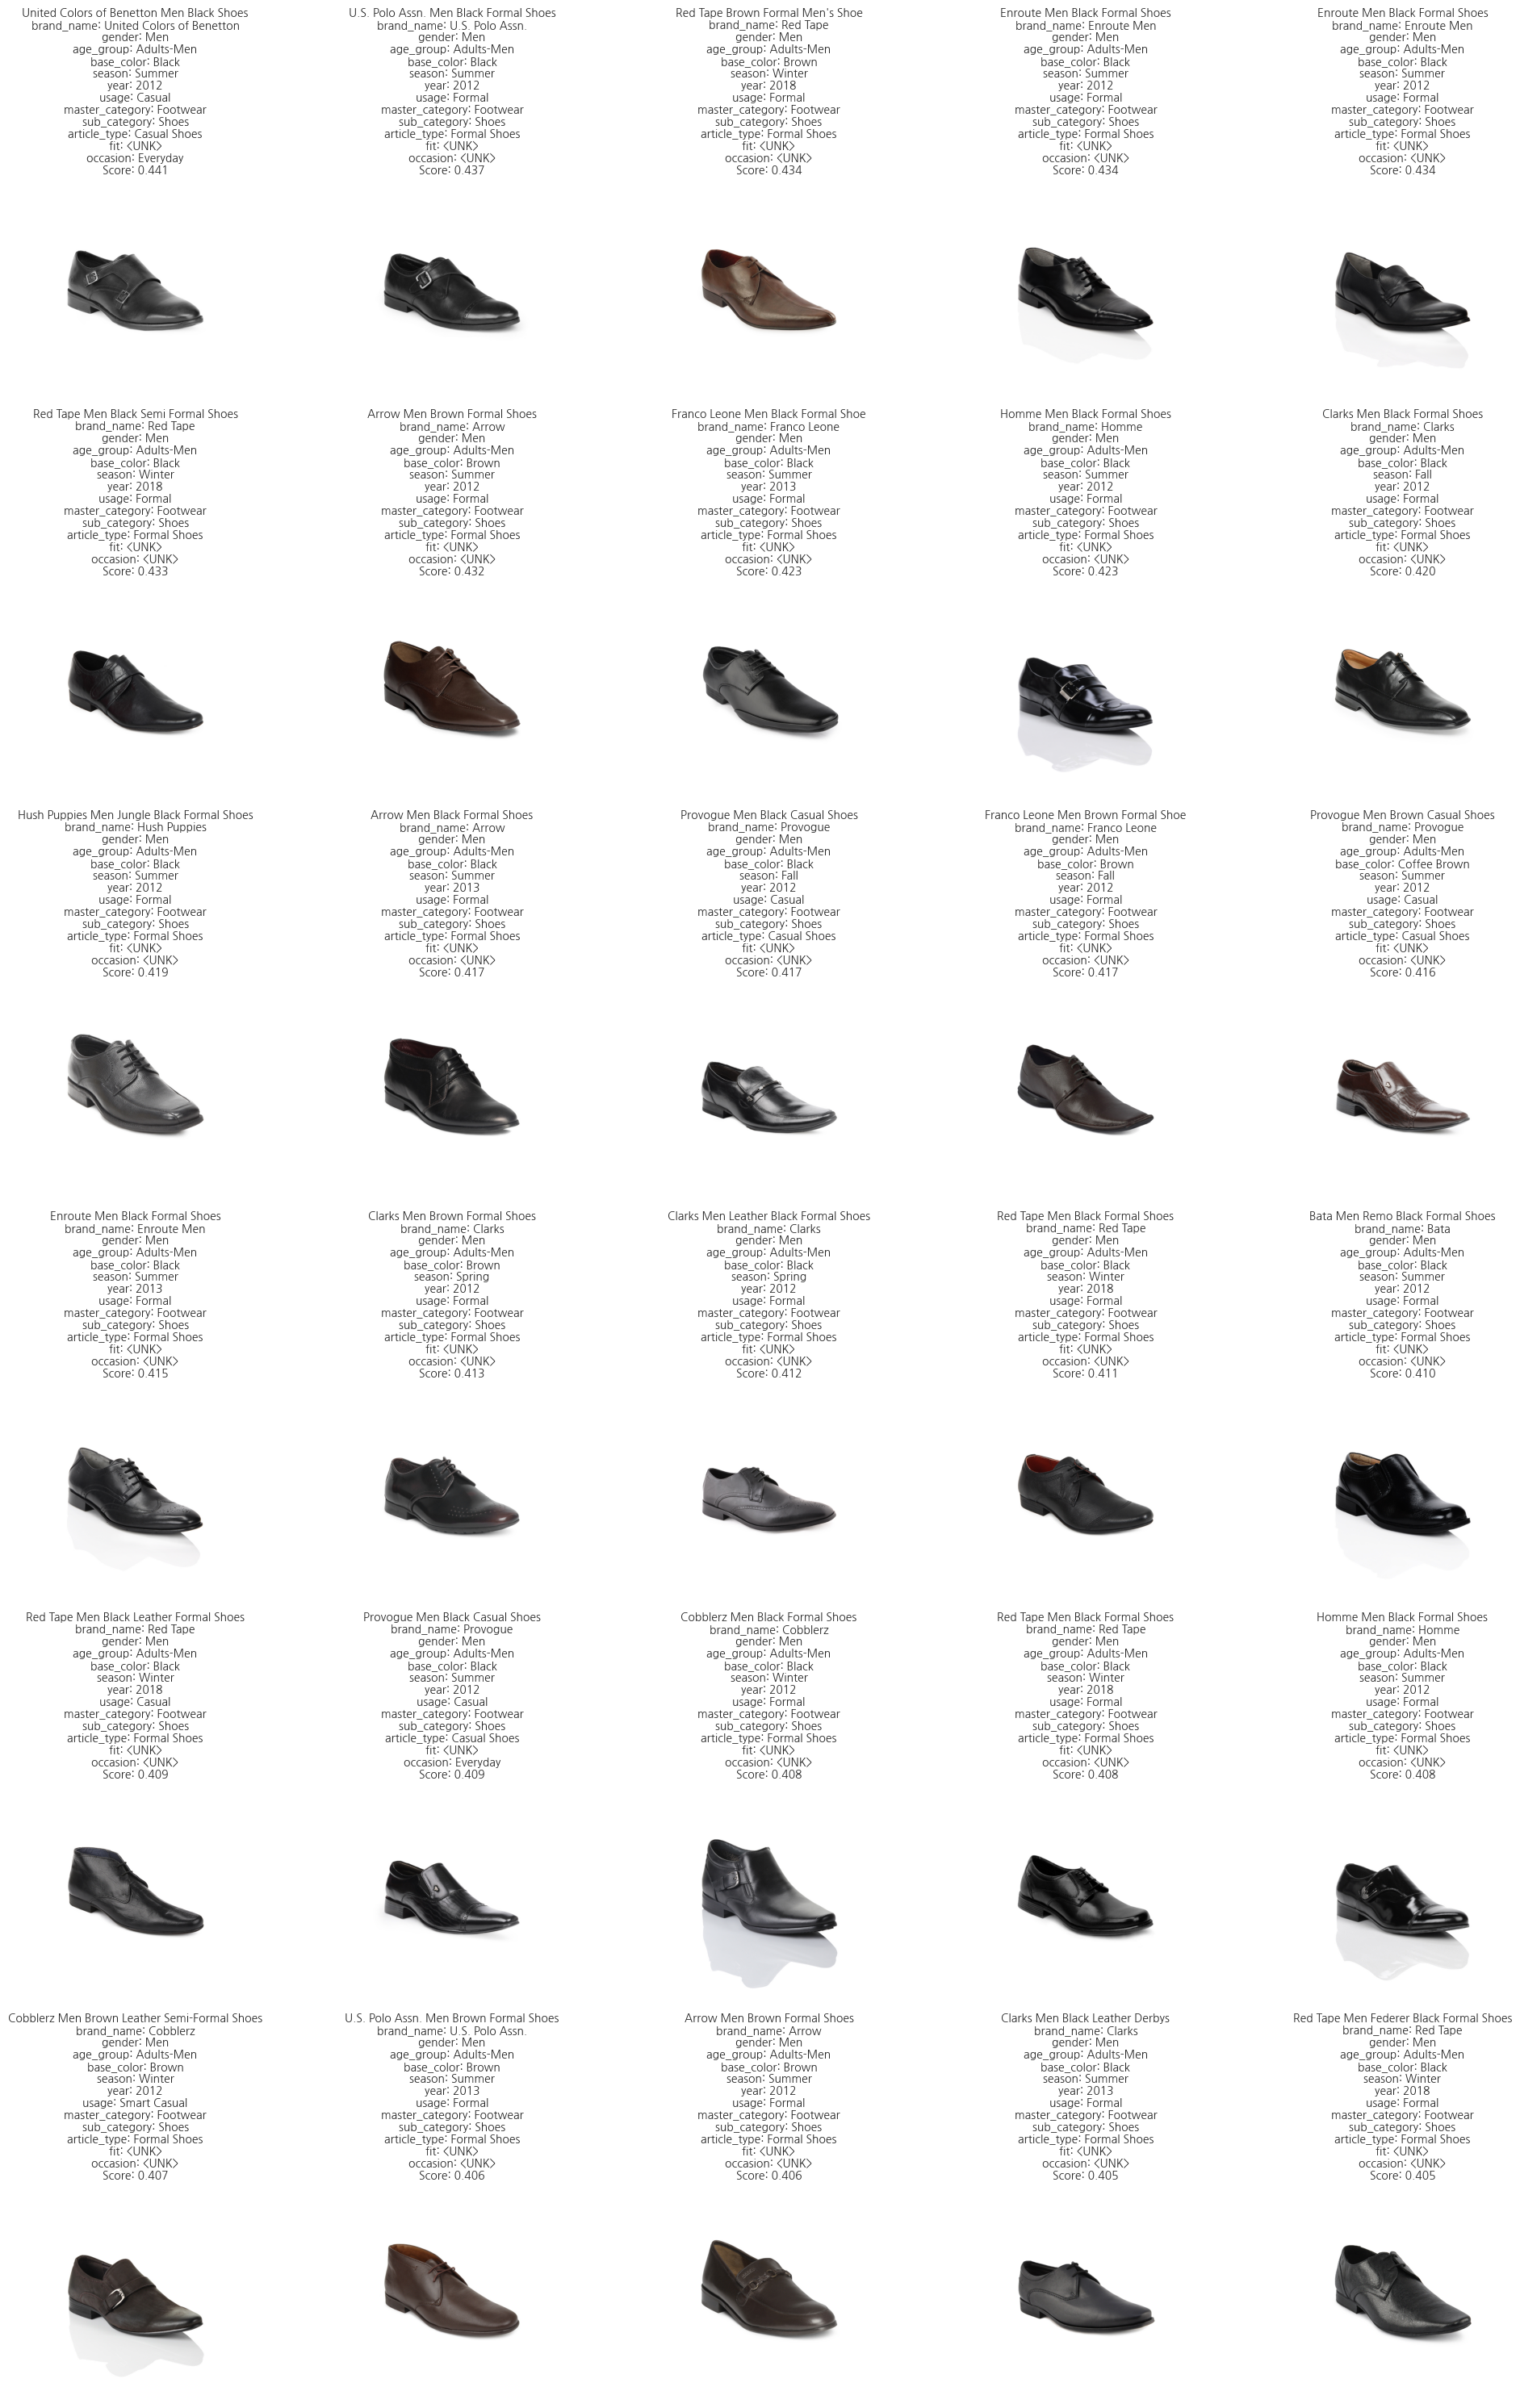

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.dataset_dir.joinpath("images"),
)